In [1]:
import importlib
import hsflfm.analysis.disk_bulk_analyzer as dba
importlib.reload(dba)

import pandas as pd
from hsflfm.util.metadata_manager import MetadataManager


from pathlib import Path
import sys

DiskBulkAnalyzer = dba.DiskBulkAnalyzer

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent

results_root = REPO_ROOT / "processed_results"
analyzer = DiskBulkAnalyzer(results_root)
analyzer.load_results()

Loaded 7 result files.


This notebook is intended as a starting point for analyzing result files that have passed through process_without_alignment in bulk for disk specimens. Later cells can create animations to see how points and vectors behave in space. 

In [ ]:
# View all loadee result files
print(results_root)
print(results_root.exists())

for path in results_root.rglob("*.json"):
    print(path)

c:\Users\abhin\HighSpeedFLFM\processed_results
True
c:\Users\abhin\HighSpeedFLFM\processed_results\results_20260511_B\20260511_B\strike_1_results.json
c:\Users\abhin\HighSpeedFLFM\processed_results\results_20260521_B\20260521_B\strike_1_results.json
c:\Users\abhin\HighSpeedFLFM\processed_results\results_20260526_B\20260526_B\strike_1_results.json
c:\Users\abhin\HighSpeedFLFM\processed_results\results_20260528_B\20260528_B\strike_1_results.json
c:\Users\abhin\HighSpeedFLFM\processed_results\results_20260602_B_1\20260602_B_1\strike_1_results.json
c:\Users\abhin\HighSpeedFLFM\processed_results\results_20260602_C_1\20260602_C_1\strike_1_results.json
c:\Users\abhin\HighSpeedFLFM\processed_results\results_20260602_C_2\20260602_C_2\strike_1_results.json


In [ ]:
# Exclude certain specimens from bulk analysis if necessary
exclude_specimens = {
    "20260511_B",
    "20260521_B",
    "20260526_B",
    # add more here as needed
}

analyzer.results = [
    r for r in analyzer.results
    if r.get("specimen_number") not in exclude_specimens
]

In [ ]:
# Basic displacment statistics across disks designated by letter

summaries = analyzer.summarize_z_displacement()
df = pd.DataFrame(summaries)

df["disk"] = df["specimen_number"].str.extract(r"_([A-F])(?:_\d+)?$")


disk_summary = (
    df.groupby("disk", dropna=False)
      .agg(
          num_runs=("specimen_number", "count"),
          mean_total_z=("total_mean_z_displacement", "mean"),
          std_total_z=("total_mean_z_displacement", "std"),
          mean_max_abs_z=("max_abs_mean_z_displacement", "mean"),
          total_points=("num_points", "sum"),
      )
      .reset_index()
)

disk_summary

,disk,num_runs,mean_total_z,std_total_z,mean_max_abs_z,total_points
0,B,2,-0.919225,0.321487,0.919225,36
1,C,2,-1.001401,0.555036,1.001401,31


In [ ]:
# See how tracked points move in real space
analyzer.animate_trial_3d(
    specimen_number="20260602_B_1",
    strike_number=1,
    fps=10,
)

Saved animation to: c:\Users\abhin\HighSpeedFLFM\processed_results\20260602_B_1_strike_1_3d_animation.mp4


WindowsPath('c:/Users/abhin/HighSpeedFLFM/processed_results/20260602_B_1_strike_1_3d_animation.mp4')

In [ ]:
# IN PROGRESS: View animated vectors on points
analyzer.animate_vector_field(
    specimen_number="20260602_B_1",
    strike_number=1,
    fps=10,
    arrow_scale=15,
)

Saved vector field animation to: c:\Users\abhin\HighSpeedFLFM\processed_results\20260602_B_1_strike_1_vector_field.mp4


WindowsPath('c:/Users/abhin/HighSpeedFLFM/processed_results/20260602_B_1_strike_1_vector_field.mp4')

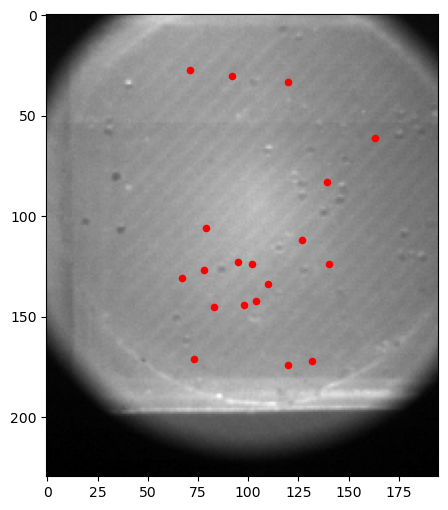

Saved vector overlay animation to: c:\Users\abhin\HighSpeedFLFM\processed_results\20260602_B_1_strike_1_camera_3_vector_overlay.mp4


WindowsPath('c:/Users/abhin/HighSpeedFLFM/processed_results/20260602_B_1_strike_1_camera_3_vector_overlay.mp4')

In [ ]:
# INCOMPLETE: Overlay vector animation on disk image
analyzer.animate_vector_field_on_image(
    specimen_number="20260602_B_1",
    strike_number=1,
    camera_key=3,
    metadata_manager= MetadataManager("20260602_B_1"),
    fps=10,
    arrow_scale=15,
    invert_z=True,
    swap_arrow_xy=True,
    flip_arrow_x=True,
    flip_arrow_y=True,
)